# ECOv003 STIC-JPL Accuracy Analysis with ECOv002 Cal-Val

This notebook performs a accuracy analysis of the STIC-JPL model using ECOSTRESS Collection 2 Cal-Val data. 

## Import Required Libraries and Functions

This cell imports all necessary libraries and functions for data processing, model execution, statistical analysis, and plotting. It includes custom modules for the JET ensemble, sensitivity analysis, and net radiation calculations, as well as standard scientific Python libraries.

In [3]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))
from typing import Callable
from os import makedirs
from os.path import join
import numpy as np
import pandas as pd
from verma_net_radiation import verma_net_radiation_table
from STIC_JPL import load_ECOv002_calval_STIC_inputs, process_STIC_table
from monte_carlo_sensitivity import perturbed_run, sensitivity_analysis, divide_absolute_by_unperturbed, sensitivity_magnitude_barchart
import matplotlib.pyplot as plt
from scipy.stats import mstats
import seaborn as sns
from matplotlib.ticker import FuncFormatter

## Configuration Options

Set configuration options for the notebook, including whether to save plots to files.

In [13]:
# Configuration: Set to True to save plots to files, False to only display them
SAVE_PLOTS = False

In [14]:
input_variables = [
    "ST_C",
    "NDVI",
    "albedo",
    "Ta_C",
    "RH",
    "AOT",
    "COT",
    "vapor_gccm",
    "ozone_cm",
    "elevation_m",
    "canopy_height_meters"
]

output_variables = [
    "Rn_Wm2",
    "ET_daylight_kg",
    "GPP_inst_g_m2_s"
]

# Per-variable physical bounds to keep perturbations realistic
input_min = {
    "ST_C": 0.0,
    "NDVI": 0.05,
    "albedo": 0.0,
    "Ta_C": 0.0,
    "RH": 0.0,
    "AOT": 0.0,
    "COT": 0.0,
    "vapor_gccm": 0.0,
    "ozone_cm": 0.0,
    "elevation_m": 0.0,
    "canopy_height_meters": 0.0,
}

input_max = {
    "ST_C": 50.0,
    "NDVI": 1,
    "albedo": 1,
}

## Define Processing Function for Model Table

This cell defines the forward process for analysis as the BESS-JPL model.

In [4]:
forward_process = process_STIC_table
model_name = "STIC-JPL"

## Set Normalization Function

This cell assigns the normalization function used to compare perturbed model outputs to the unperturbed baseline. The function `divide_absolute_by_unperturbed` is used for normalization in the sensitivity analysis.

In [5]:
normalization_function = divide_absolute_by_unperturbed

## Load and Filter Input Data

This cell loads the ECOSTRESS Cal-Val input data using a custom loader function and filters out surface temperatures greater than 50 Celsius and NDVI values less than 0.05. The resulting DataFrame is displayed for inspection.

In [7]:
input_df = load_ECOv002_calval_STIC_inputs()

# Apply lower and upper bounds from configuration dictionaries
mask = pd.Series(True, index=input_df.index)
for var, min_val in input_min.items():
    if var in input_df.columns:
        mask &= input_df[var] >= min_val
for var, max_val in input_max.items():
    if var in input_df.columns:
        mask &= input_df[var] <= max_val

input_df = input_df[mask]
input_df = input_df.dropna()
input_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,KG_climate,CI,canopy_height_meters,COT,AOT,Ca,wind_speed_mps,vapor_gccm,ozone_cm,Rn_Wm2
15,15,US-xAB,ENF,Csb,141.635670,168.24043,402.81810,159.71700,139.016083,107.183200,...,3,0.188235,6.244725,0,0,400,0,0,0.3,404.03476
17,17,US-xAB,ENF,Csb,1.881266,163.94730,301.40400,179.13661,131.273636,106.525215,...,3,0.188235,6.244725,0,0,400,0,0,0.3,302.23804
18,18,US-xAB,ENF,Csb,3.135606,246.87700,614.51480,405.50497,366.056641,222.890230,...,3,0.188235,6.244725,0,0,400,0,0,0.3,616.39750
19,19,US-xAB,ENF,Csb,311.482820,290.73126,672.27510,478.82382,439.821228,153.787670,...,3,0.188235,6.244725,0,0,400,0,0,0.3,674.41180
20,20,US-xAB,ENF,Csb,51.920338,95.28810,116.67136,73.20884,232.693512,24.038680,...,3,0.188235,6.244725,0,0,400,0,0,0.3,116.89754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,992,US-xML,DBF,Dfb,417.831120,706.93066,523.92740,310.69684,356.174072,148.624050,...,4,0.262745,23.197309,0,0,400,0,0,0.3,525.16113
994,994,US-xML,DBF,Dfb,161.558200,306.15277,420.44678,206.48576,237.659103,98.727560,...,4,0.262745,23.197309,0,0,400,0,0,0.3,421.50970
1001,1001,US-UiB,CRO,Dfa,93.876100,251.38747,238.71077,198.90399,106.316444,67.694800,...,4,0.290196,0.000000,0,0,400,0,0,0.3,477.29570
1020,1020,US-ARM,CRO,Cfa,80.255005,0.00000,180.10085,211.28325,164.581390,84.672410,...,3,0.298039,0.000000,0,0,400,0,0,0.3,354.62286


## Process Input Data Through Model

This cell applies the processing function to the filtered input data, running it through the model, and displays the resulting DataFrame.

In [8]:
processed = forward_process(input_df)
processed

[2026-07-30 14:21:20 INFO] started extracting geometry from STIC-JPL input table
[2026-07-30 14:21:20 INFO] completed extracting geometry from STIC-JPL input table
[2026-07-30 14:21:20 INFO] started extracting time from STIC-JPL input table
[2026-07-30 14:21:20 INFO] completed extracting time from STIC-JPL input table
[2026-07-30 14:21:20 INFO] variable Ms min: 0.000 mean: 0.194 max: 0.691 nan: 0.00% (nan)
[2026-07-30 14:21:20 INFO] running STIC iteration 1 / 30
[2026-07-30 14:21:20 INFO] iterating without solar
[2026-07-30 14:21:20 INFO] using variable Priestley-Taylor alpha with mean: 1.198
[2026-07-30 14:21:20 INFO] completed STIC iteration 1 / 30 with max LE change: 309.947 (0.0011808749986812472 seconds)
[2026-07-30 14:21:20 INFO] variable SM_1 min: 0.000 mean: 0.103 max: 0.691 nan: 0.00% (nan)
[2026-07-30 14:21:20 INFO] variable G_1 min: 2.018 mean: 55.329 max: 131.748 nan: 0.00% (nan)
[2026-07-30 14:21:20 INFO] variable LE_1 min: 2.911 mean: 176.611 max: 527.830 nan: 0.00% (nan)

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,Rn_Wm2,LE_max_change,iteration,LE_Wm2,LE_change,LE_soil_Wm2,LE_canopy_Wm2,potential_transpiration_Wm2,PET_Wm2,G_Wm2
15,15,US-xAB,ENF,Csb,141.635670,168.24043,402.81810,159.71700,139.016083,107.183200,...,404.03476,1.859131,19,233.861945,1.798529e-02,76.753913,157.108031,353.411957,401.910359,20.527767
17,17,US-xAB,ENF,Csb,1.881266,163.94730,301.40400,179.13661,131.273636,106.525215,...,302.23804,1.859131,19,282.597829,7.359419e-01,185.641553,96.956276,343.407218,415.601371,11.209452
18,18,US-xAB,ENF,Csb,3.135606,246.87700,614.51480,405.50497,366.056641,222.890230,...,616.39750,1.859131,19,410.666126,1.023774e-01,87.023351,323.642775,650.177601,708.044131,28.358606
19,19,US-xAB,ENF,Csb,311.482820,290.73126,672.27510,478.82382,439.821228,153.787670,...,674.41180,1.859131,19,367.496299,4.289623e-03,36.114339,331.381960,667.466466,698.552012,35.609646
20,20,US-xAB,ENF,Csb,51.920338,95.28810,116.67136,73.20884,232.693512,24.038680,...,116.89754,1.859131,19,48.714954,0.000000e+00,0.000000,48.714954,68.458796,68.458796,2.018278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,992,US-xML,DBF,Dfb,417.831120,706.93066,523.92740,310.69684,356.174072,148.624050,...,525.16113,1.859131,19,491.047733,1.859131e+00,259.755543,231.292190,758.045871,952.260620,24.147919
994,994,US-xML,DBF,Dfb,161.558200,306.15277,420.44678,206.48576,237.659103,98.727560,...,421.50970,1.859131,19,404.149350,0.000000e+00,233.475972,170.673378,750.649566,967.400245,17.360350
1001,1001,US-UiB,CRO,Dfa,93.876100,251.38747,238.71077,198.90399,106.316444,67.694800,...,477.29570,1.859131,19,70.157522,9.693565e-09,15.665719,54.491803,240.582830,280.885479,62.101563
1020,1020,US-ARM,CRO,Cfa,80.255005,0.00000,180.10085,211.28325,164.581390,84.672410,...,354.62286,1.859131,19,130.406375,3.799850e-04,13.024819,117.381556,307.665018,326.105918,52.152892


[2026-07-30 15:01:35 INFO] started extracting geometry from STIC-JPL input table
[2026-07-30 15:01:35 INFO] completed extracting geometry from STIC-JPL input table
[2026-07-30 15:01:35 INFO] started extracting time from STIC-JPL input table
[2026-07-30 15:01:35 INFO] completed extracting time from STIC-JPL input table
[2026-07-30 15:01:35 INFO] variable Ms min: 0.000 mean: 0.215 max: 0.949 nan: 0.00% (nan)
analyzing MALLICK2014 STIC-JPL accuracy for LE_Wm2 compared to insitu_LE_Wm2


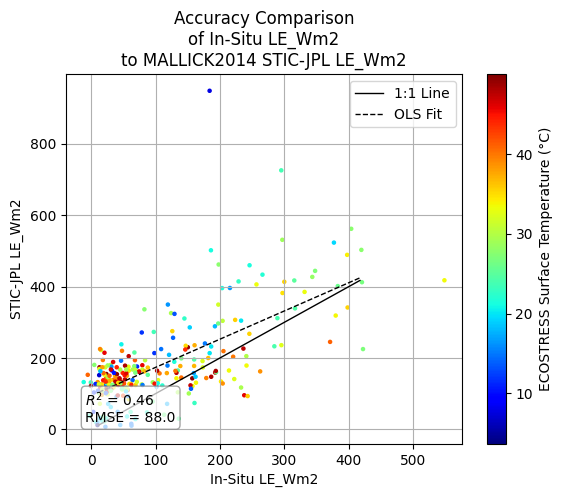

[2026-07-30 15:01:35 INFO] started extracting geometry from STIC-JPL input table
[2026-07-30 15:01:35 INFO] completed extracting geometry from STIC-JPL input table
[2026-07-30 15:01:35 INFO] started extracting time from STIC-JPL input table
[2026-07-30 15:01:35 INFO] completed extracting time from STIC-JPL input table
[2026-07-30 15:01:35 INFO] variable Ms min: 0.000 mean: 0.215 max: 0.949 nan: 0.00% (nan)
[2026-07-30 15:01:35 INFO] running STIC iteration 1 / 25
[2026-07-30 15:01:35 INFO] iterating without solar
[2026-07-30 15:01:35 INFO] using variable Priestley-Taylor alpha with mean: 1.134
[2026-07-30 15:01:35 INFO] completed STIC iteration 1 / 25 with max LE change: 214.6 (0.0011422080024203751 seconds)
[2026-07-30 15:01:35 INFO] variable SM_1 min: 0.000 mean: 0.130 max: 0.949 nan: 0.00% (nan)
[2026-07-30 15:01:35 INFO] variable G_1 min: 2.018 mean: 55.329 max: 131.748 nan: 0.00% (nan)
[2026-07-30 15:01:35 INFO] variable LE_1 min: 19.059 mean: 181.598 max: 1112.956 nan: 0.00% (nan)

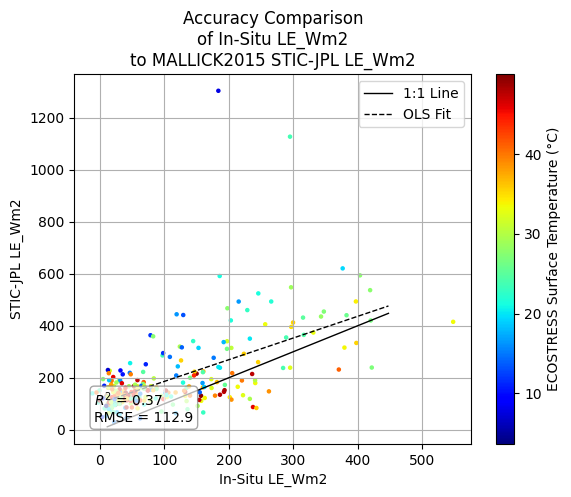

[2026-07-30 15:01:36 INFO] started extracting geometry from STIC-JPL input table
[2026-07-30 15:01:36 INFO] completed extracting geometry from STIC-JPL input table
[2026-07-30 15:01:36 INFO] started extracting time from STIC-JPL input table
[2026-07-30 15:01:36 INFO] completed extracting time from STIC-JPL input table
[2026-07-30 15:01:36 INFO] variable Ms min: 0.000 mean: 0.215 max: 0.949 nan: 0.00% (nan)
[2026-07-30 15:01:36 INFO] running STIC iteration 1 / 25
[2026-07-30 15:01:36 INFO] iterating without solar
[2026-07-30 15:01:36 INFO] using variable Priestley-Taylor alpha with mean: 1.134
[2026-07-30 15:01:36 INFO] completed STIC iteration 1 / 25 with max LE change: 214.6 (0.0009654999994381797 seconds)
[2026-07-30 15:01:36 INFO] variable SM_1 min: 0.000 mean: 0.130 max: 0.949 nan: 0.00% (nan)
[2026-07-30 15:01:36 INFO] variable G_1 min: 2.018 mean: 55.329 max: 131.748 nan: 0.00% (nan)
[2026-07-30 15:01:36 INFO] variable LE_1 min: 19.059 mean: 181.598 max: 1112.956 nan: 0.00% (nan)

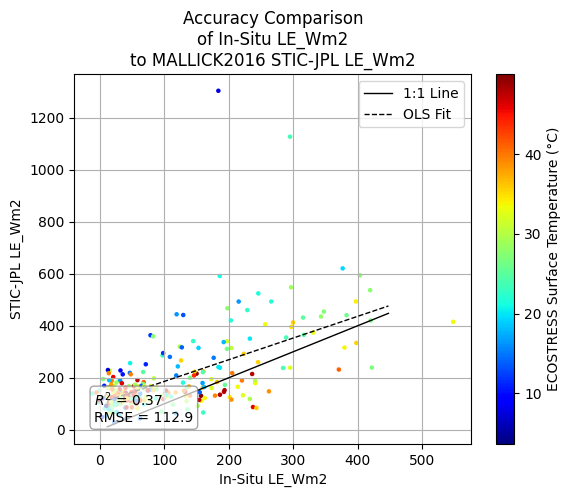

[2026-07-30 15:01:36 INFO] ECOv002 mode: using Rg column as SWin_Wm2
[2026-07-30 15:01:36 INFO] started extracting geometry from STIC-JPL input table
[2026-07-30 15:01:36 INFO] completed extracting geometry from STIC-JPL input table
[2026-07-30 15:01:36 INFO] started extracting time from STIC-JPL input table
[2026-07-30 15:01:36 INFO] completed extracting time from STIC-JPL input table
[2026-07-30 15:01:36 INFO] variable Ms min: 0.000 mean: 0.249 max: 0.691 nan: 0.00% (nan)
[2026-07-30 15:01:36 INFO] running STIC iteration 1 / 3
[2026-07-30 15:01:36 INFO] iterating with solar
[2026-07-30 15:01:36 INFO] using variable Priestley-Taylor alpha with mean: 1.257
[2026-07-30 15:01:36 INFO] completed STIC iteration 1 / 3 with max LE change: 311.453 (0.0011883750012202654 seconds)
[2026-07-30 15:01:36 INFO] variable SM_1 min: 0.035 mean: 0.160 max: 1.000 nan: 0.00% (nan)
[2026-07-30 15:01:36 INFO] variable G_1 min: -23.571 mean: 84.537 max: 189.084 nan: 0.00% (nan)
[2026-07-30 15:01:36 INFO] va

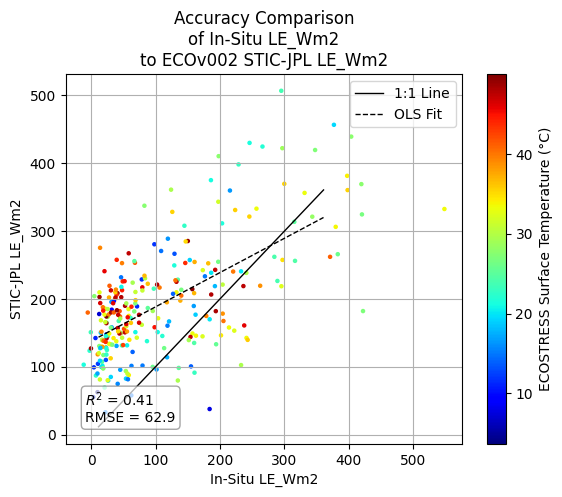

[2026-07-30 15:01:36 INFO] started extracting geometry from STIC-JPL input table
[2026-07-30 15:01:36 INFO] completed extracting geometry from STIC-JPL input table
[2026-07-30 15:01:36 INFO] started extracting time from STIC-JPL input table
[2026-07-30 15:01:36 INFO] completed extracting time from STIC-JPL input table
[2026-07-30 15:01:36 INFO] variable Ms min: 0.000 mean: 0.194 max: 0.691 nan: 0.00% (nan)
[2026-07-30 15:01:36 INFO] running STIC iteration 1 / 30
[2026-07-30 15:01:36 INFO] iterating without solar
[2026-07-30 15:01:36 INFO] using variable Priestley-Taylor alpha with mean: 1.198
[2026-07-30 15:01:36 INFO] completed STIC iteration 1 / 30 with max LE change: 309.947 (0.0009582080019754358 seconds)
[2026-07-30 15:01:36 INFO] variable SM_1 min: 0.000 mean: 0.103 max: 0.691 nan: 0.00% (nan)
[2026-07-30 15:01:36 INFO] variable G_1 min: 2.018 mean: 55.329 max: 131.748 nan: 0.00% (nan)
[2026-07-30 15:01:36 INFO] variable LE_1 min: 2.911 mean: 176.611 max: 527.830 nan: 0.00% (nan)

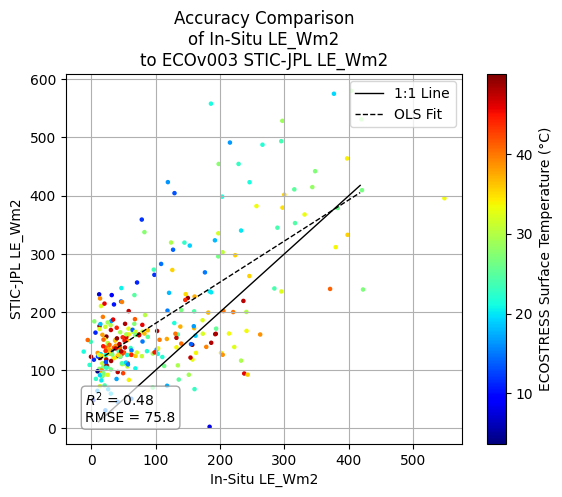

In [24]:
for configuration in ["MALLICK2014", "MALLICK2015", "MALLICK2016", "ECOv002", "ECOv003"]:
    def forward_process(*args, **kwargs):
        kwargs["configuration"] = configuration
        return process_STIC_table(*args, **kwargs)

    processed = forward_process(input_df)

    print(f"analyzing {configuration} {model_name} accuracy for {output_variable} compared to {insitu_variable}")
        
    x_variable = insitu_variable
    y_variable = output_variable

    # Filter out rows with NaN values in either variable
    valid_data = processed[[x_variable, y_variable, 'ST_C']].dropna()
    
    sc = plt.scatter(
        x=valid_data[x_variable],
        y=valid_data[y_variable],
        c=valid_data.ST_C,
        cmap="jet",
        color=None,
        s=5
    )

    # Calculate 5% and 95% tails for x and y variables
    x_5th, x_95th = np.percentile(valid_data[x_variable], [5, 95])
    y_5th, y_95th = np.percentile(valid_data[y_variable], [5, 95])

    min_val = min(x_5th, y_5th)
    max_val = max(x_95th, y_95th)

    # Add 1-to-1 line
    # min_val = min(valid_data[x_variable].min(), valid_data[y_variable].min())
    # max_val = max(valid_data[x_variable].max(), valid_data[y_variable].max())
    plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

    # Add OLS regression line
    coefs = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)
    ols_x = np.array([min_val, max_val])
    ols_y = coefs[0] * ols_x + coefs[1]
    plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

    # Calculate R-squared and RMSE
    from sklearn.metrics import r2_score, mean_squared_error
    y_true = valid_data[y_variable]
    y_pred = coefs[0] * valid_data[x_variable] + coefs[1]
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Annotate R-squared and RMSE on plot in lower left corner
    plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
                xy=(0.05, 0.05), xycoords='axes fraction',
                ha='left', va='bottom',
                fontsize=10,
                bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

    # Set ticks every 100 for both axes
    # xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
    # yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
    # plt.xticks(xticks)
    # plt.yticks(yticks)

    plt.grid(True, zorder=0) 
    plt.xlabel(f"In-Situ {output_variable}")
    plt.ylabel(f"{model_name} {output_variable}")
    plt.title(f"Accuracy Comparison\nof In-Situ {output_variable}\nto {configuration} {model_name} {output_variable}")
    plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
    plt.legend(loc='upper right')
    
    plt.show()

## Accuracy Comparison of In-Situ Observations to Model Estimates

Examining the accuracy of model estimates compared to ground data.

analyzing STIC-JPL accuracy for ET_daylight_kg compared to insitu_ET_daylight_kg
Error processing ET_daylight_kg: "['ET_daylight_kg'] not in index"
analyzing STIC-JPL accuracy for G_Wm2 compared to insitu_G_Wm2


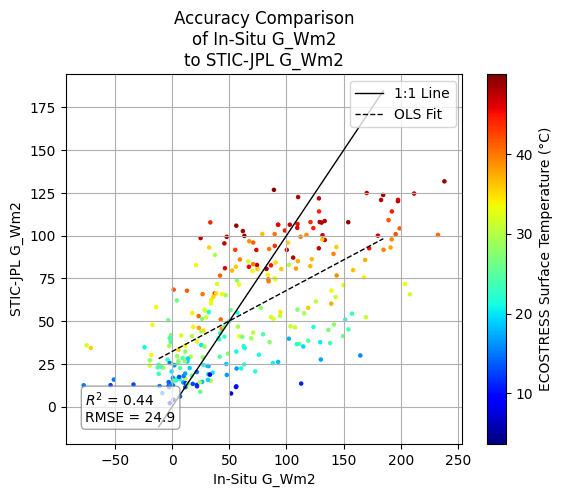

analyzing STIC-JPL accuracy for H_Wm2 compared to insitu_H_Wm2
Error processing H_Wm2: "['H_Wm2'] not in index"
analyzing STIC-JPL accuracy for LE_Wm2 compared to insitu_LE_Wm2


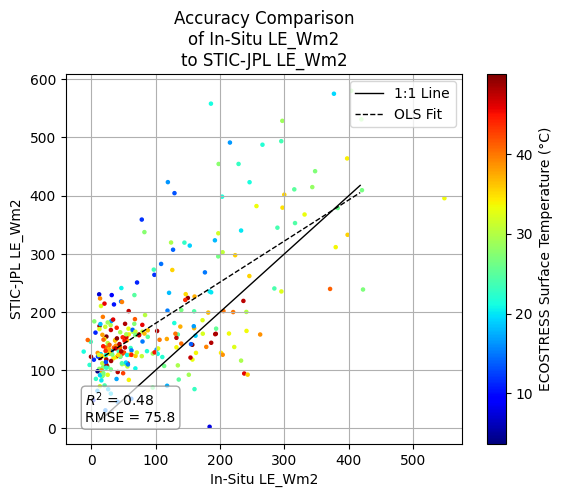

analyzing STIC-JPL accuracy for LE_daylight_Wm2 compared to insitu_LE_daylight_Wm2
Error processing LE_daylight_Wm2: "['LE_daylight_Wm2'] not in index"
analyzing STIC-JPL accuracy for Rn_Wm2 compared to insitu_Rn_Wm2


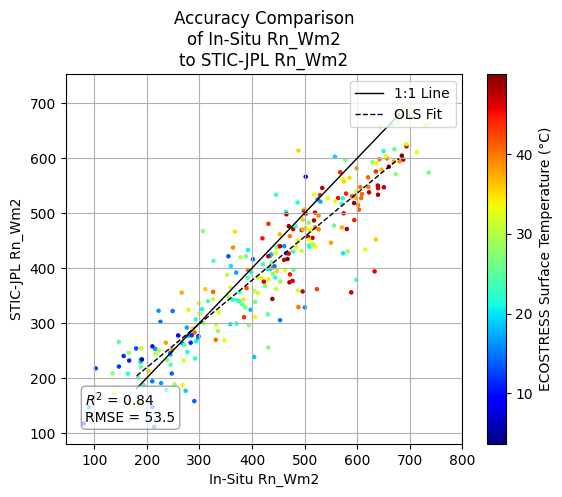

analyzing STIC-JPL accuracy for Rn_daylight_Wm2 compared to insitu_Rn_daylight_Wm2
Error processing Rn_daylight_Wm2: "['Rn_daylight_Wm2'] not in index"
analyzing STIC-JPL accuracy for SWin_Wm2 compared to insitu_SWin_Wm2


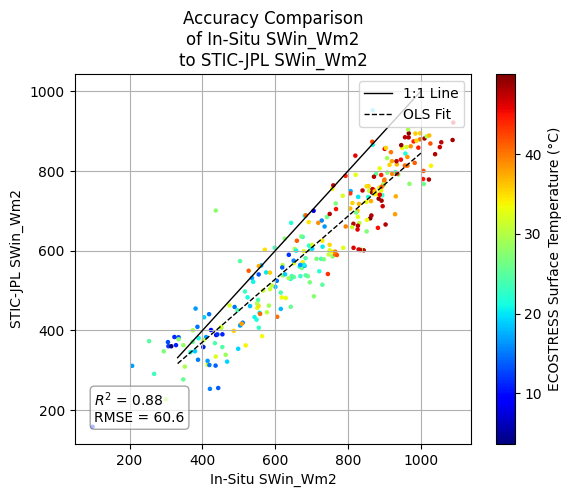

In [15]:
insitu_columns = sorted([column for column in processed.columns if "insitu" in column])

for insitu_variable in insitu_columns:
    try:
        output_variable = insitu_variable.replace("insitu_", "")
        print(f"analyzing {model_name} accuracy for {output_variable} compared to {insitu_variable}")
        
        x_variable = insitu_variable
        y_variable = output_variable

        # Filter out rows with NaN values in either variable
        valid_data = processed[[x_variable, y_variable, 'ST_C']].dropna()
        
        sc = plt.scatter(
            x=valid_data[x_variable],
            y=valid_data[y_variable],
            c=valid_data.ST_C,
            cmap="jet",
            color=None,
            s=5
        )

        # Calculate 5% and 95% tails for x and y variables
        x_5th, x_95th = np.percentile(valid_data[x_variable], [5, 95])
        y_5th, y_95th = np.percentile(valid_data[y_variable], [5, 95])

        min_val = min(x_5th, y_5th)
        max_val = max(x_95th, y_95th)

        # Add 1-to-1 line
        # min_val = min(valid_data[x_variable].min(), valid_data[y_variable].min())
        # max_val = max(valid_data[x_variable].max(), valid_data[y_variable].max())
        plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

        # Add OLS regression line
        coefs = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)
        ols_x = np.array([min_val, max_val])
        ols_y = coefs[0] * ols_x + coefs[1]
        plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

        # Calculate R-squared and RMSE
        from sklearn.metrics import r2_score, mean_squared_error
        y_true = valid_data[y_variable]
        y_pred = coefs[0] * valid_data[x_variable] + coefs[1]
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # Annotate R-squared and RMSE on plot in lower left corner
        plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
                    xy=(0.05, 0.05), xycoords='axes fraction',
                    ha='left', va='bottom',
                    fontsize=10,
                    bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

        # Set ticks every 100 for both axes
        # xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # plt.xticks(xticks)
        # plt.yticks(yticks)

        plt.grid(True, zorder=0) 
        plt.xlabel(f"In-Situ {output_variable}")
        plt.ylabel(f"{model_name} {output_variable}")
        plt.title(f"Accuracy Comparison\nof In-Situ {output_variable}\nto {model_name} {output_variable}")
        plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
        plt.legend(loc='upper right')
        
        if SAVE_PLOTS:
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.jpeg", format='jpeg', bbox_inches='tight')
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.svg", format='svg', bbox_inches='tight')
        
        plt.show()
    except Exception as e:
        print(f"Error processing {output_variable}: {e}")
        continue

# Accuracy Comparison for Net Radiation between BESS and Verma

analyzing STIC-JPL accuracy for Rn_Wm2 compared to insitu_Rn_Wm2


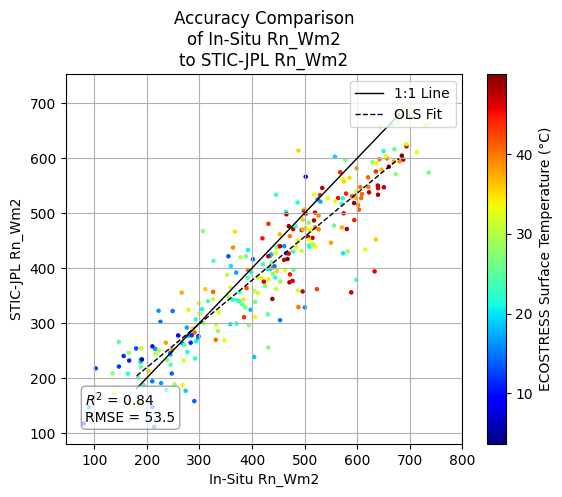

In [17]:
insitu_variable = "insitu_Rn_Wm2"

for output_variable in ["Rn_Wm2"]:
    try:
        print(f"analyzing {model_name} accuracy for {output_variable} compared to {insitu_variable}")
        
        x_variable = insitu_variable
        y_variable = output_variable

        # Filter out rows with NaN values in either variable
        valid_data = processed[[x_variable, y_variable, 'ST_C']].dropna()
        
        sc = plt.scatter(
            x=valid_data[x_variable],
            y=valid_data[y_variable],
            c=valid_data.ST_C,
            cmap="jet",
            color=None,
            s=5
        )

        # Calculate 5% and 95% tails for x and y variables
        x_5th, x_95th = np.percentile(valid_data[x_variable], [5, 95])
        y_5th, y_95th = np.percentile(valid_data[y_variable], [5, 95])

        min_val = min(x_5th, y_5th)
        max_val = max(x_95th, y_95th)

        # Add 1-to-1 line
        # min_val = min(valid_data[x_variable].min(), valid_data[y_variable].min())
        # max_val = max(valid_data[x_variable].max(), valid_data[y_variable].max())
        plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

        # Add OLS regression line
        coefs = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)
        ols_x = np.array([min_val, max_val])
        ols_y = coefs[0] * ols_x + coefs[1]
        plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

        # Calculate R-squared and RMSE
        from sklearn.metrics import r2_score, mean_squared_error
        y_true = valid_data[y_variable]
        y_pred = coefs[0] * valid_data[x_variable] + coefs[1]
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # Annotate R-squared and RMSE on plot in lower left corner
        plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
                    xy=(0.05, 0.05), xycoords='axes fraction',
                    ha='left', va='bottom',
                    fontsize=10,
                    bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

        # Set ticks every 100 for both axes
        # xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # plt.xticks(xticks)
        # plt.yticks(yticks)

        plt.grid(True, zorder=0) 
        plt.xlabel(f"In-Situ {output_variable}")
        plt.ylabel(f"{model_name} {output_variable}")
        plt.title(f"Accuracy Comparison\nof In-Situ {output_variable}\nto {model_name} {output_variable}")
        plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
        plt.legend(loc='upper right')
        
        if SAVE_PLOTS:
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.jpeg", format='jpeg', bbox_inches='tight')
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.svg", format='svg', bbox_inches='tight')
        
        plt.show()
    except Exception as e:
        print(f"Error processing {output_variable}: {e}")
        continue

analyzing STIC-JPL accuracy for LE_Wm2 compared to insitu_LE_Wm2


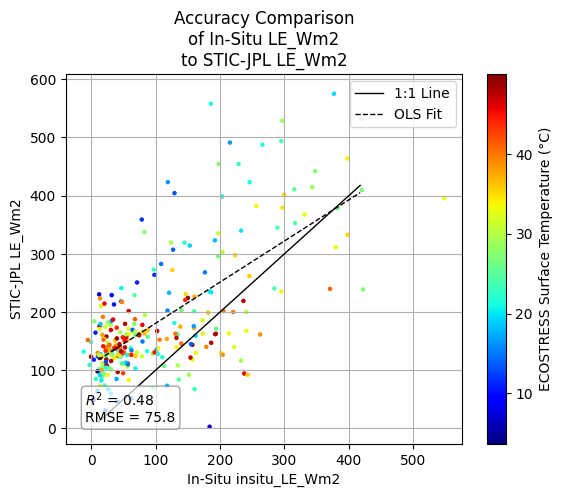

In [18]:
insitu_variable = "insitu_LE_Wm2"

output_variables = [
    "LE_Wm2"
]

for output_variable in output_variables:
    try:
        print(f"analyzing {model_name} accuracy for {output_variable} compared to {insitu_variable}")
        
        x_variable = insitu_variable
        y_variable = output_variable

        # Filter out rows with NaN values in either variable
        valid_data = processed[[x_variable, y_variable, 'ST_C']].dropna()
        
        sc = plt.scatter(
            x=valid_data[x_variable],
            y=valid_data[y_variable],
            c=valid_data.ST_C,
            cmap="jet",
            color=None,
            s=5
        )

        # Calculate 5% and 95% tails for x and y variables
        x_5th, x_95th = np.percentile(valid_data[x_variable], [5, 95])
        y_5th, y_95th = np.percentile(valid_data[y_variable], [5, 95])

        min_val = min(x_5th, y_5th)
        max_val = max(x_95th, y_95th)

        # Add 1-to-1 line
        # min_val = min(valid_data[x_variable].min(), valid_data[y_variable].min())
        # max_val = max(valid_data[x_variable].max(), valid_data[y_variable].max())
        plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

        # Add OLS regression line
        coefs = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)
        ols_x = np.array([min_val, max_val])
        ols_y = coefs[0] * ols_x + coefs[1]
        plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

        # Calculate R-squared and RMSE
        from sklearn.metrics import r2_score, mean_squared_error
        y_true = valid_data[y_variable]
        y_pred = coefs[0] * valid_data[x_variable] + coefs[1]
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # Annotate R-squared and RMSE on plot in lower left corner
        plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
                    xy=(0.05, 0.05), xycoords='axes fraction',
                    ha='left', va='bottom',
                    fontsize=10,
                    bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

        # Set ticks every 100 for both axes
        # xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # plt.xticks(xticks)
        # plt.yticks(yticks)

        plt.grid(True, zorder=0) 
        plt.xlabel(f"In-Situ {insitu_variable}")
        plt.ylabel(f"{model_name} {output_variable}")
        plt.title(f"Accuracy Comparison\nof In-Situ {output_variable}\nto {model_name} {output_variable}")
        plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
        plt.legend(loc='upper right')
        
        if SAVE_PLOTS:
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.jpeg", format='jpeg', bbox_inches='tight')
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.svg", format='svg', bbox_inches='tight')
        
        plt.show()
    except Exception as e:
        print(f"Error processing {output_variable}: {e}")
        continue


## Plot Unperturbed Comparison of Surface Temperature to Net Radiation

This cell creates a scatter plot comparing ECOSTRESS surface temperature to net radiation for the unperturbed data. The plot is saved as both JPEG and SVG files for publication or further analysis.

In [ ]:
plt.scatter(x=processed.ST_C, y=processed.Rn_Wm2, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel(f"{model_name} Net Radiation (W/m$^2$)")
plt.title(f"Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto {model_name} Net Radiation", pad=20)

if SAVE_PLOTS:
    plt.savefig(f"Unperturbed Comparison of ECOSTRESS Surface Temperature to {model_name} Net Radiation.jpeg", format='jpeg', bbox_inches='tight')
    plt.savefig(f"Unperturbed Comparison of ECOSTRESS Surface Temperature to {model_name} Net Radiation.svg", format='svg', bbox_inches='tight')

plt.show()

## Plot Unperturbed Comparison of Surface Temperature to Evapotranspiration

This cell creates a scatter plot comparing ECOSTRESS surface temperature to BESS-JPL evapotranspiration for the unperturbed data. The plot is saved as both JPEG and SVG files for publication or further analysis.

In [ ]:
plt.xticks(range(int(min(processed.ST_C)), int(max(processed.ST_C)) + 1, 5))
plt.scatter(x=processed.ST_C, y=processed.ET_daylight_kg, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel(f"{model_name} Evapotranspiration (mm/day)")
plt.title(f"Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto {model_name} Evapotranspiration")

if SAVE_PLOTS:
    plt.savefig(f"Unperturbed Comparison of ECOSTRESS Surface Temperature to {model_name} Evapotranspiration.jpeg", format='jpeg', bbox_inches='tight')
    plt.savefig(f"Unperturbed Comparison of ECOSTRESS Surface Temperature to {model_name} Evapotranspiration.svg", format='svg', bbox_inches='tight')

plt.show()